Evaluate the dataset for suitability to apply a Linear Regression algorithm

The dataset is suitable for linear regression.

• The target variable, charges, is continuous
• The dataset contains relevant predictors: age, sex, bmi, children, smoker, region
• No missing values are present
• One duplicate row will be removed

The relationships between variables support regression:

• Age shows a positive relationship with charges
• BMI shows a moderate relationship
• Smoking status has a strong effect on charges

How i plan my analysis

a. Exploratory Data Analysis

I will:

• Check dataset structure
• Check missing values and duplicates
• Analyse distributions
• Use visualisations to study relationships
• Create correlation matrix

b. Feature selection

I will:

• Encode categorical variables
• Analyse relationships with charges
• Select relevant features
• Check multicollinearity

c. Train model

I will:

• Split the dataset
• Train a Linear Regression model
• Use default parameters

d. Interpret and evaluate model

I will:

• Use R squared
• Use Mean Absolute Error
• Use Mean Squared Error
• Analyse predictions and residuals

e. Write a report

The report will include:

• Data cleaning steps
• EDA findings
• Model training
• Model evaluation

I will conduct my analysis

a. Exploratory Data Analysis

Data Loading

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Dataset Overview

In [60]:
print(df.shape)
print(df.info())

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


Data Cleaning

In [61]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()
print("New shape:", df.shape)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicates: 1
New shape: (1337, 7)


Summary Statistics

In [62]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


Distribution of Variables

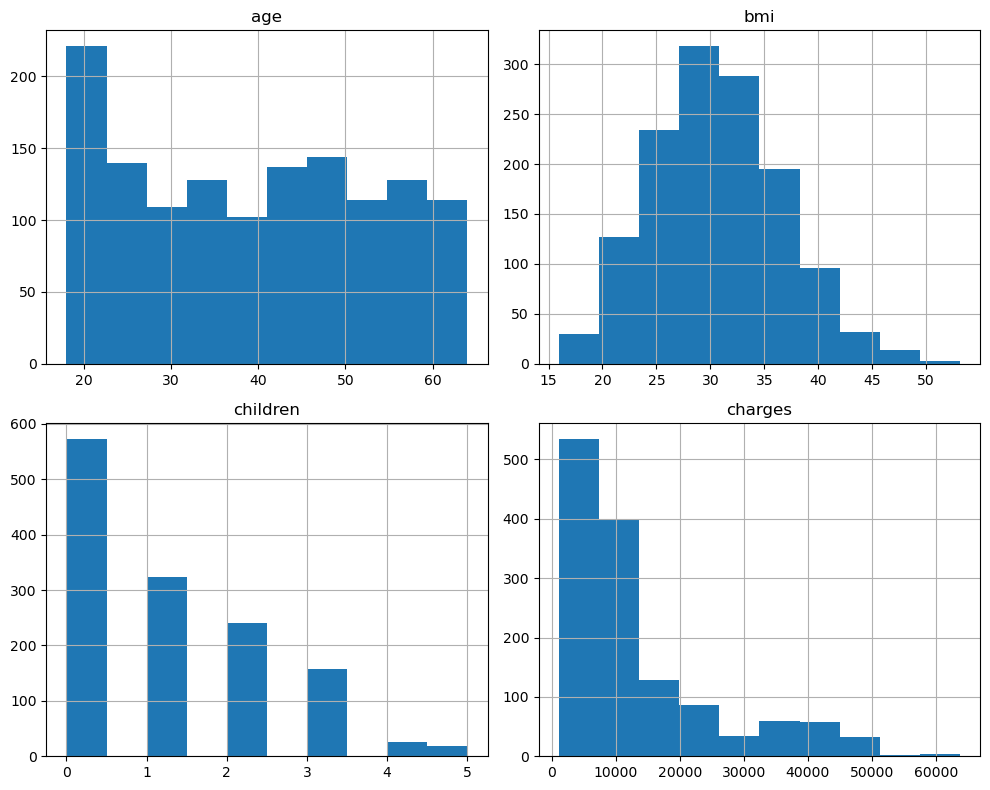

In [63]:
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

Scatterplots

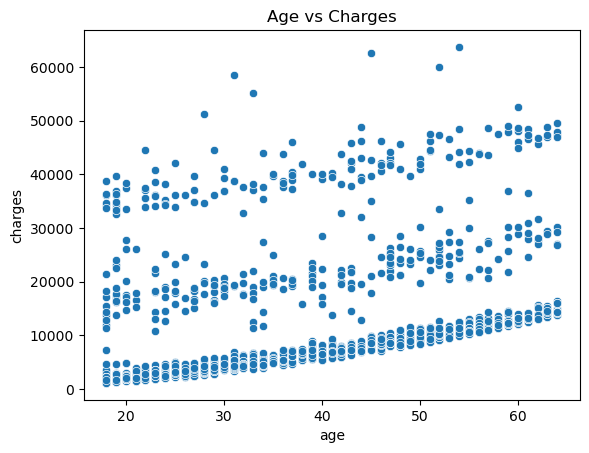

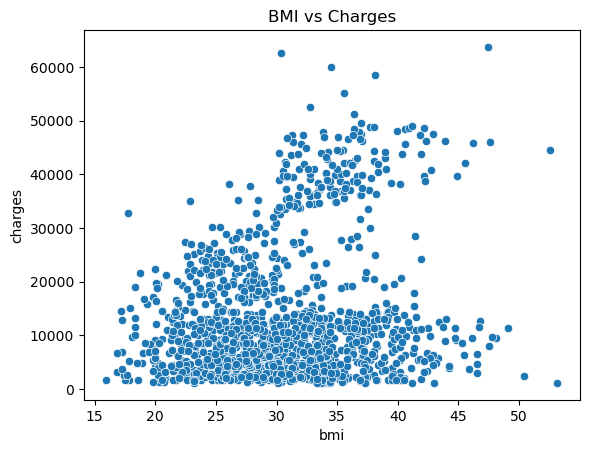

In [64]:
sns.scatterplot(data=df, x="age", y="charges")
plt.title("Age vs Charges")
plt.show()

sns.scatterplot(data=df, x="bmi", y="charges")
plt.title("BMI vs Charges")
plt.show()

Smoking Impact

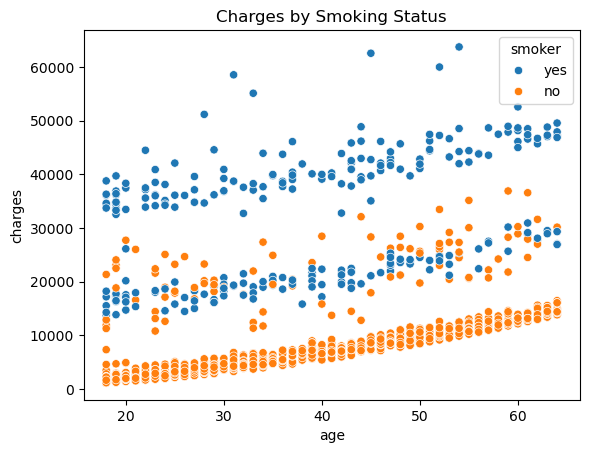

In [65]:
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")
plt.title("Charges by Smoking Status")
plt.show()

Pairplot

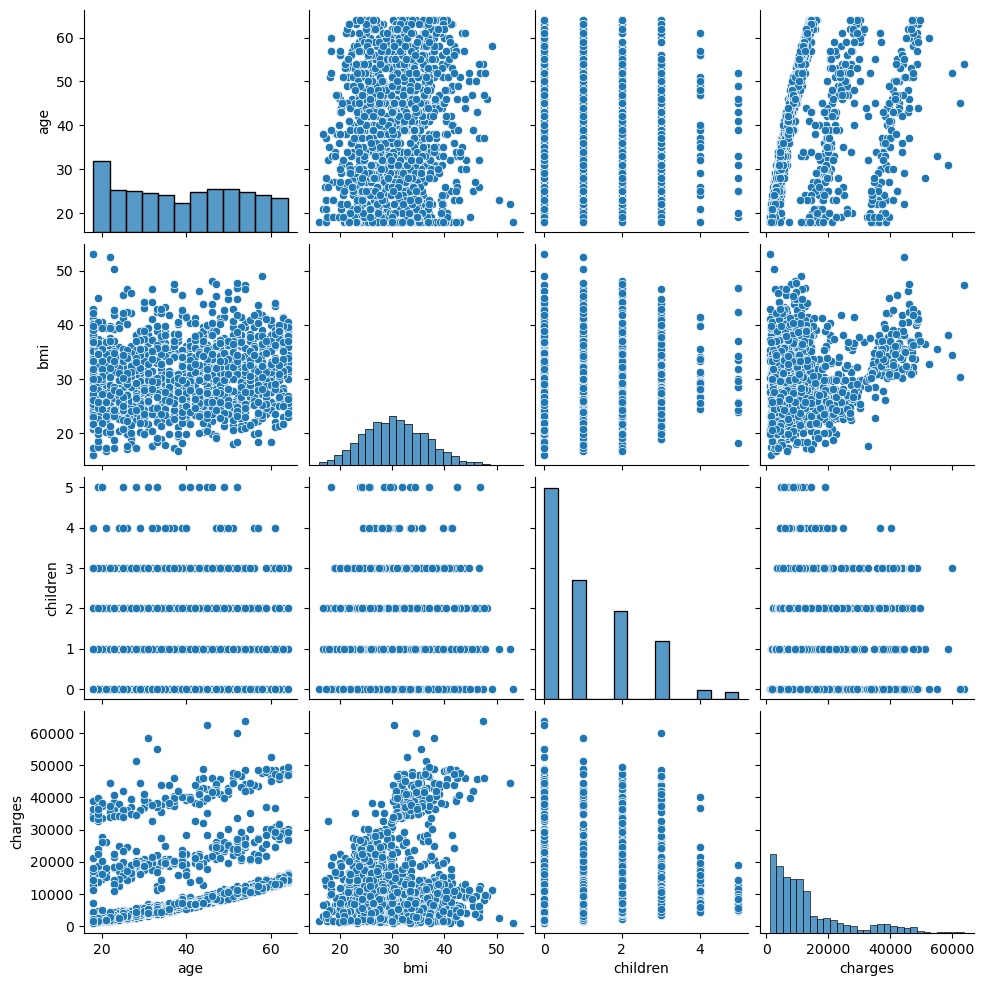

In [66]:
sns.pairplot(df[["age","bmi","children","charges"]])
plt.show()

Correlation Matrix

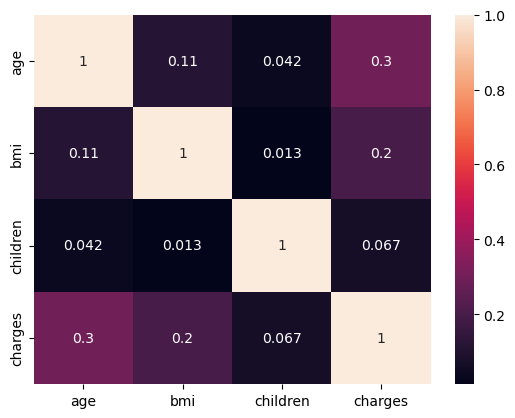

In [67]:
corr = df[["age","bmi","children","charges"]].corr()
sns.heatmap(corr, annot=True)
plt.show()

Boxplots for Outliers

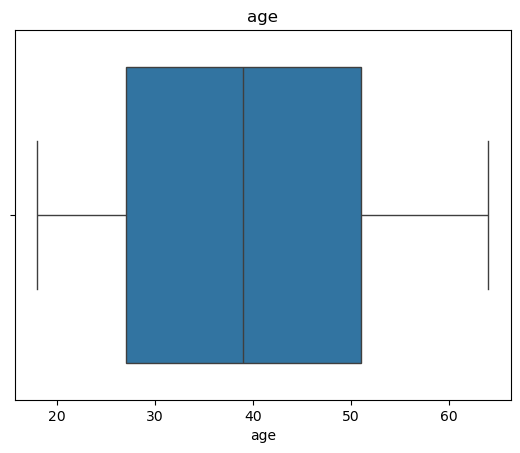

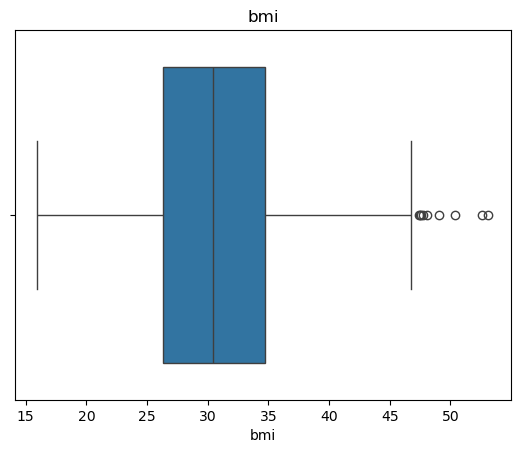

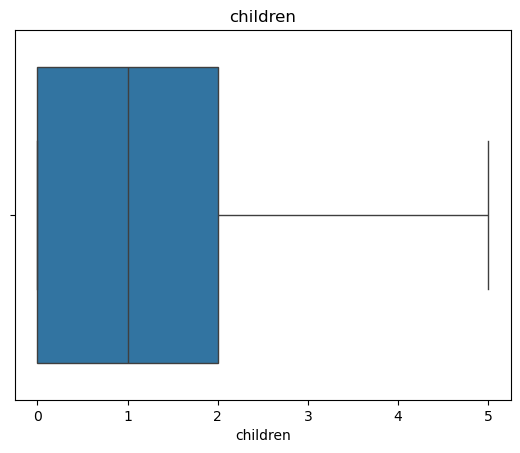

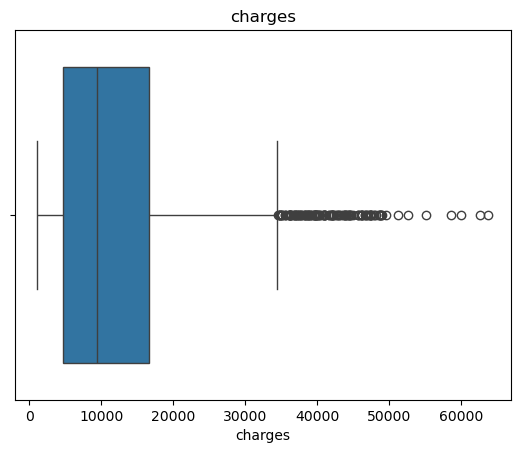

In [68]:
cols = ["age","bmi","children","charges"]

for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Grouped Analysis

In [69]:
print(df.groupby("smoker")["charges"].mean())
print(df.groupby("sex")["charges"].mean())
print(df.groupby("region")["charges"].mean())

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64
sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64
region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64


b. Feature selection

Encoding categorical variables

In [70]:
df["sex"] = df["sex"].map({"male":0, "female":1})
df["smoker"] = df["smoker"].map({"no":0, "yes":1})

df = pd.get_dummies(df, columns=["region"], drop_first=True)

df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


Selecting features

In [71]:
X = df.drop("charges", axis=1)
y = df["charges"]

print(X.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')


c. Train model

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained")

Model trained


Evaluate your model

a. Interpret and evaluate model

In [73]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R2: 0.8069287081198011
MAE: 4177.045561036321
MSE: 35478020.675235614
RMSE: 5956.342894363589


Visual Evaluation

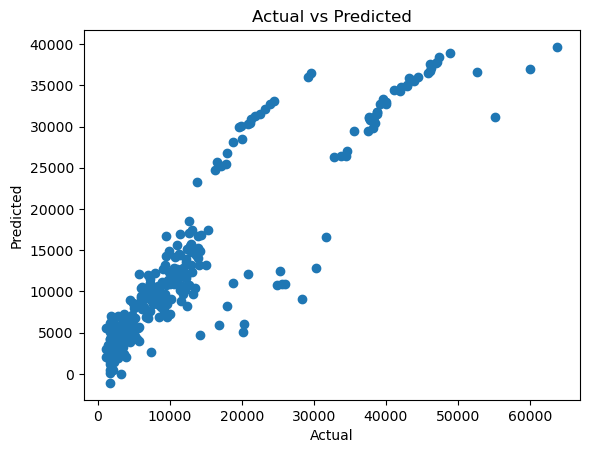

In [74]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

Residual Analysis

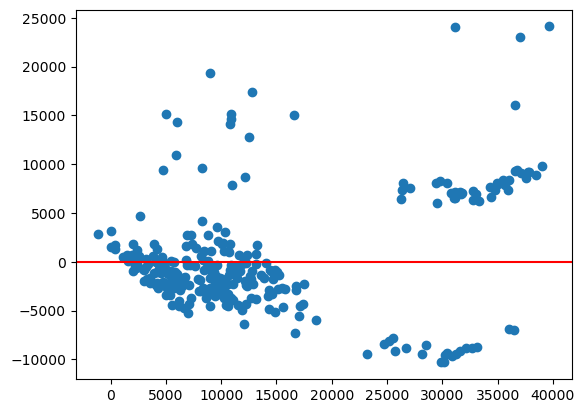

In [75]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red")
plt.show()

b. Retrain with different parameters

The model used default parameters. The performance was acceptable, so no retraining was required.

The dataset was clean and suitable for linear regression. Exploratory Data Analysis showed clear relationships between predictors and charges. Smoking status had the strongest impact, followed by age and BMI. The model performed well based on evaluation metrics. The results show that the model can predict medical charges with reasonable accuracy.